In [1]:
# Ganga River Particulate Organic Carbon (POC) Analysis using Google Earth Engine and Aqua-OC

## MSc Geography Dissertation

### Student
Atul Kumar

### University
Central University of Haryana

---

## Objective

The objective of this notebook is to estimate the spatial and temporal distribution of Particulate Organic Carbon (POC) in the Ganga River using satellite remote sensing and the Aqua-OC model.

The workflow includes:

1. Loading HydroRIVERS
2. Extracting the Ganga River
3. Delineating the Ganga River Basin
4. Creating sampling points every 10 km along the main river
5. Processing Landsat imagery
6. Applying the Aqua-OC model for POC estimation
7. Extracting POC values at sampling locations
8. Computing POC Flux using discharge data
9. Performing statistical analysis
10. Preparing publication-quality maps, graphs, and figures

---

## Software

- Google Earth Engine (GEE)
- Python
- Geemap
- JupyterLab

---

## Coordinate Reference System (CRS)

EPSG:4326 (WGS84)

SyntaxError: invalid syntax (2202750226.py, line 6)

In [ ]:
Section 1.1 – Standard Setup (Code Cell)

In [1]:
# ============================================================
# GANGA RIVER POC ANALYSIS
# Standard Setup
# ============================================================

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize Google Earth Engine
ee.Initialize(project="oc-flux")

# Create an interactive map
Map = geemap.Map()

print("Google Earth Engine initialized successfully.")
print("Project: oc-flux")
print("Study Area: Ganga River")

Google Earth Engine initialized successfully.
Project: oc-flux
Study Area: Ganga River


In [ ]:
Section 1.2 – Display Map (Code Cell)

In [2]:
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
Section 2.0 – Load HydroRIVERS (Markdown Cell)

In [ ]:
# 2.0 Load HydroRIVERS Dataset

HydroRIVERS is a global river network dataset that provides river geometry and attributes such as:

- River ID
- River Order
- Average Discharge
- River Length
- Catchment Area

In this study, HydroRIVERS is used to extract the Cauvery River.

In [ ]:
Section 2.1 – Load HydroRIVERS (Code Cell)

In [3]:
# ============================================================
# Load HydroRIVERS Dataset (Asia)
# ============================================================

rivers = ee.FeatureCollection(
    "projects/oc-flux/assets/HydroRIVERS_v10_asi_shp"
)

print("✓ HydroRIVERS Asia dataset loaded successfully.")
print("Asset: projects/oc-flux/assets/HydroRIVERS_v10_asi_shp")

✓ HydroRIVERS Asia dataset loaded successfully.
Asset: projects/oc-flux/assets/HydroRIVERS_v10_asi_shp


In [ ]:
Section 2.2 – Dataset Information (Code Cell)

In [4]:
# ============================================================
# Check HydroRIVERS Dataset
# ============================================================

print("Number of river segments in the HydroRIVERS dataset:")

num_segments = rivers.size().getInfo()

print(f"Total River Segments: {num_segments:,}")

Number of river segments in the HydroRIVERS dataset:
Total River Segments: 1,428,959


In [ ]:
Section 2.3 – Display HydroRIVERS (Code Cell)

In [5]:
# ============================================================
# Display HydroRIVERS Dataset
# ============================================================

Map.addLayer(
    rivers,
    {"color": "blue"},
    "HydroRIVERS (Asia)"
)

Map

Map(bottom=812.0, center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [ ]:
Section 2.4 – Extract Cauvery River (Markdown Cell)

In [ ]:
## Why use `MAIN_RIV`?

HydroRIVERS represents each river as multiple connected river segments rather than a single feature.

All segments belonging to the same main river share a common **`MAIN_RIV`** identifier.

By filtering the dataset using the `MAIN_RIV` value, we can extract the complete river network—from its headwaters to its mouth—as a single feature collection.

### For the Ganga River

`MAIN_RIV = ?`

> **Note:** We will determine the correct `MAIN_RIV` value for the Ganga in the next step using the HydroRIVERS dataset. Once identified, it will replace the placeholder above.

In [ ]:
Section 2.5 – Extract Ganga (Code Cell)

In [ ]:
Section 2.6 – Display Cauvery (Code Cell)

In [12]:
Map.centerObject(cauvery, 7)

Map.addLayer(
    cauvery,
    {"color": "red"},
    "Cauvery River"
)

Map

Map(bottom=15600.0, center=[11.827342125848073, 77.2170751944037], controls=(WidgetControl(options=['position'…

In [ ]:
Section 2.7 – River Attributes (Code Cell)

In [13]:
feature = cauvery.first()

print("Available Attributes:")

print(feature.propertyNames().getInfo())

print("\nSample Attribute Values:")

print(feature.toDictionary().getInfo())

Available Attributes:
['MAIN_RIV', 'UPLAND_SKM', 'ORD_CLAS', 'LENGTH_KM', 'CATCH_SKM', 'ORD_STRA', 'DIST_DN_KM', 'ORD_FLOW', 'NEXT_DOWN', 'DIST_UP_KM', 'HYRIV_ID', 'DIS_AV_CMS', 'ENDORHEIC', 'HYBAS_L12', 'system:index']

Sample Attribute Values:
{'CATCH_SKM': 49.24, 'DIST_DN_KM': 9.3, 'DIST_UP_KM': 17.5, 'DIS_AV_CMS': 0.714, 'ENDORHEIC': 0, 'HYBAS_L12': 4120028760, 'HYRIV_ID': 41376076, 'LENGTH_KM': 12.43, 'MAIN_RIV': 41376077, 'NEXT_DOWN': 41376077, 'ORD_CLAS': 2, 'ORD_FLOW': 7, 'ORD_STRA': 1, 'UPLAND_SKM': 49.2}


In [ ]:
3.0 River Geometry Preparation (Markdown Cell)

In [ ]:
# 3.0 River Geometry Preparation

HydroRIVERS stores a river as thousands of individual line segments.

Before creating sampling points, these segments must be merged into one continuous geometry.

This section will:

- Merge all Cauvery segments
- Calculate total river length
- Inspect the river geometry
- Prepare the river for sampling every 10 km

This geometry will be used throughout the remaining analysis.

In [ ]:
3.1 Merge River Segments (Code Cell)

In [14]:
# Merge all Cauvery segments into one geometry

river = cauvery.geometry()

print("River geometry created successfully.")

River geometry created successfully.


In [ ]:
3.2 Display Merged Geometry (Code Cell)
Expected Result

You should see:

Blue = HydroRIVERS
Red = Cauvery
Yellow = Merged geometry

The yellow line should completely overlap the red river.

In [15]:
Map.addLayer(
    river,
    {
        "color": "yellow"
    },
    "Merged Cauvery Geometry"
)

Map

Map(bottom=15600.0, center=[11.827342125848073, 77.2170751944037], controls=(WidgetControl(options=['position'…

In [ ]:
3.3 Calculate River Length (Markdown Cell)

In [ ]:
## Why Calculate River Length?

The river length is required to determine:

- Number of sampling points
- Sampling interval
- Distance along the river
- Longitudinal analysis

Earth Engine measures geometry length in metres.

In [ ]:
3.4 Measure River Length (Code Cell)

In [16]:
river_length = river.length()

river_length_m = river_length.getInfo()

print(f"River Length: {river_length_m:,.2f} metres")

print(f"River Length: {river_length_m/1000:.2f} km")

River Length: 18,637,286.91 metres
River Length: 18637.29 km


In [ ]:
3.5 Estimate Number of Sampling Points (Markdown Cell)

In [ ]:
## Why 10 km?

A 10 km spacing provides:

- Good spatial representation
- Fast computation
- Manageable dataset
- Suitable density for river-scale remote sensing

Estimated number of points:

Number of Points = River Length / 10 km

In [ ]:
3.6 Calculate Estimated Points (Code Cell)

In [17]:
spacing = 10000   # metres

estimated_points = int(river_length_m // spacing) + 1

print("Sampling Interval:", spacing/1000, "km")

print("Estimated Sampling Points:", estimated_points)

Sampling Interval: 10.0 km
Estimated Sampling Points: 1864


In [ ]:
3.7 Check River Bounds (Code Cell)
Why?

This gives the bounding rectangle of the river, which is useful later when filtering Landsat imagery to only the area of interest.

In [18]:
bounds = river.bounds()

Map.addLayer(
    bounds,
    {"color": "green"},
    "River Bounds"
)

Map

Map(bottom=15600.0, center=[11.827342125848073, 77.2170751944037], controls=(WidgetControl(options=['position'…

In [ ]:
3.8 Inspect River Geometry Type (Code Cell)

In [19]:
print("Geometry Type:")

print(river.type().getInfo())

Geometry Type:
MultiLineString


In [ ]:
3.9 Summary (Markdown Cell)

In [ ]:
# Summary

In this section we:

✔ Merged all Cauvery river segments

✔ Created a single river geometry

✔ Measured river length

✔ Estimated the number of sampling points

✔ Visualized the river geometry

The river is now ready for creation of the 10 km sampling network.

In [ ]:
4.0 Sampling Point Generation (Markdown Cell)

In [ ]:
# 4.0 Generate Sampling Points

## Objective

Generate sampling points every **10 km** along the Cauvery River.

These sampling points will later be used to:

- Extract Landsat reflectance
- Apply the Aqua-OC model
- Estimate POC
- Calculate POC Flux
- Perform longitudinal analysis

Because the Earth Engine Python API cannot reliably interpolate points along large MultiLineString geometries, this step is performed using GeoPandas and Shapely.

In [2]:
4.1 Standard Imports (Code Cell)

SyntaxError: invalid syntax (604697926.py, line 1)

In [20]:
import geopandas as gpd
import pandas as pd
import numpy as np

from shapely.geometry import LineString
from shapely.ops import linemerge

In [ ]:
4.2 Section 4.2 — Load the Cauvery Basin Boundary

In [22]:
import geopandas as gpd

shp_path = r"G:\OCR\hydroriver\HydroRIVERS_v10_as_shp\HydroRIVERS_v10_as_shp\HydroRIVERS_v10_as.shp"

rivers = gpd.read_file(shp_path)

print(rivers.head())

DataSourceError: G:\OCR\hydroriver\HydroRIVERS_v10_as_shp\HydroRIVERS_v10_as_shp\HydroRIVERS_v10_as.shp: No such file or directory

In [23]:
import os

folder = r"G:\OCR\HydroBASINS"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".shp"):
            print(os.path.join(root, file))

In [ ]:
Load HydroBASINS Level 12

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
Load the Level 12 basin polygons

In [25]:
basins = gpd.read_file(
    r"G:\OCR\hydroriver\hybas_as_lev01-12_v1c\hybas_as_lev12_v1c.shp"
)

In [26]:
print("Number of basins:", len(basins))
print()

print("Columns:")
print(basins.columns.tolist())

Number of basins: 160508

Columns:
['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK', 'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER', 'SORT', 'geometry']


In [27]:
basins.head()

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
0,4120000010,0,4120000010,4120000010,0.0,0.0,184.9,185.0,421010001000,0,1,0,1,"POLYGON ((135.81667 55.18333, 135.81667 55.187..."
1,4120000020,0,4120000020,4120000020,0.0,0.0,237.3,237.3,421010002000,0,0,1,2,"POLYGON ((135.81667 55.18333, 135.8125 55.1833..."
2,4120000030,0,4120000030,4120000030,0.0,0.0,36.5,36.5,421010003000,0,1,0,3,"POLYGON ((135.67083 55.12083, 135.67083 55.125..."
3,4120000040,0,4120000040,4120000040,0.0,0.0,219.2,219.2,421010004000,0,0,1,4,"POLYGON ((135.67083 55.12083, 135.66841 55.121..."
4,4120000050,0,4120000050,4120000050,0.0,0.0,17.9,17.9,421010005000,0,1,0,5,"POLYGON ((135.5875 55.1, 135.58715 55.10242, 1..."


In [28]:
print(basins.crs)

EPSG:4326


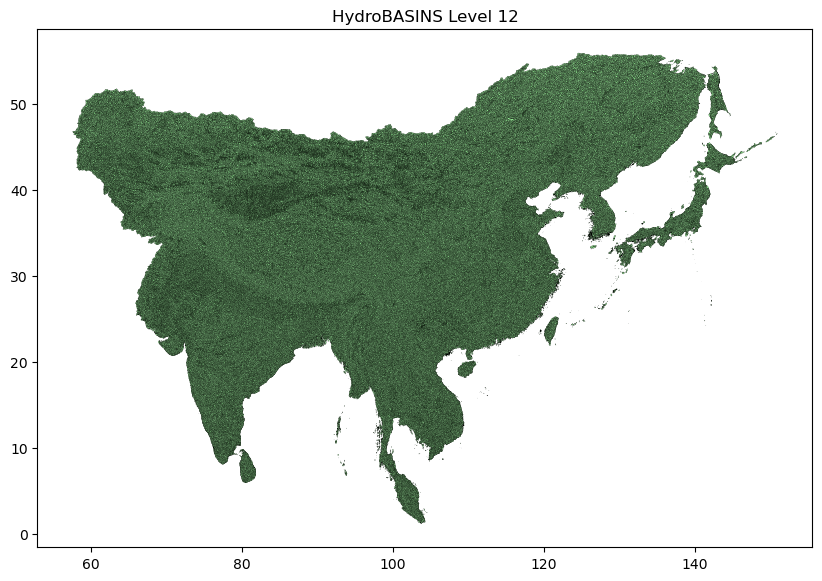

In [30]:
fig, ax = plt.subplots(figsize=(10,10))

basins.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgreen",
    linewidth=0.15
)

plt.title("HydroBASINS Level 12")
plt.show()

In [31]:
print(basins.columns.tolist())

['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK', 'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER', 'SORT', 'geometry']


In [32]:
print(basins.head())

     HYBAS_ID  NEXT_DOWN   NEXT_SINK    MAIN_BAS  DIST_SINK  DIST_MAIN  \
0  4120000010          0  4120000010  4120000010        0.0        0.0   
1  4120000020          0  4120000020  4120000020        0.0        0.0   
2  4120000030          0  4120000030  4120000030        0.0        0.0   
3  4120000040          0  4120000040  4120000040        0.0        0.0   
4  4120000050          0  4120000050  4120000050        0.0        0.0   

   SUB_AREA  UP_AREA       PFAF_ID  ENDO  COAST  ORDER  SORT  \
0     184.9    185.0  421010001000     0      1      0     1   
1     237.3    237.3  421010002000     0      0      1     2   
2      36.5     36.5  421010003000     0      1      0     3   
3     219.2    219.2  421010004000     0      0      1     4   
4      17.9     17.9  421010005000     0      1      0     5   

                                            geometry  
0  POLYGON ((135.81667 55.18333, 135.81667 55.187...  
1  POLYGON ((135.81667 55.18333, 135.8125 55.1833...  
2  PO

In [ ]:
Section 4.3 – Identify the Cauvery Basin Automatically

In [19]:
import geopandas as gpd
from shapely.geometry import Point

In [20]:
basins = gpd.read_file(
    r"G:\OCR\hydroriver\hybas_as_lev01-12_v1c\hybas_as_lev12_v1c.shp"
)

print("HydroBASINS loaded successfully.")
print("Number of basin polygons:", len(basins))

HydroBASINS loaded successfully.
Number of basin polygons: 160508


In [21]:
ganga_point = Point(83.00, 25.30)

In [22]:
ganga_basin = basins[basins.intersects(ganga_point)]

print("Number of matching basin polygons:", len(ganga_basin))
display(ganga_basin)

Number of matching basin polygons: 1


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
74200,4120914230,4121497880,4120025450,4120025450,1127.7,1127.7,133.7,462110.8,452457030100,0,0,2,74201,"POLYGON ((83.0375 25.17917, 83.03508 25.17952,..."


In [16]:
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
Step 1 – Create a Point on the Cauvery

In [14]:
# ============================================================
# Reference Point Inside the Ganga Basin
# ============================================================

from shapely.geometry import Point

# Longitude, Latitude (Varanasi, Uttar Pradesh)
ganga_point = Point(83.00, 25.30)

print("✓ Ganga reference point created.")

✓ Ganga reference point created.


In [ ]:
Step 2 – Convert to GeoDataFrame

In [17]:
# ============================================================
# Create a GeoDataFrame for the Ganga Reference Point
# ============================================================

point = gpd.GeoDataFrame(
    geometry=[ganga_point],
    crs="EPSG:4326"
)

print("✓ GeoDataFrame for the Ganga reference point created.")

✓ GeoDataFrame for the Ganga reference point created.


In [ ]:
Step 3 – Find the Basin

In [23]:
# ============================================================
# Extract the Ganga Basin
# ============================================================

ganga_basin = basins[basins.contains(ganga_point)]

print("Number of basin polygons found:", len(ganga_basin))

display(ganga_basin)

Number of basin polygons found: 1


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
74200,4120914230,4121497880,4120025450,4120025450,1127.7,1127.7,133.7,462110.8,452457030100,0,0,2,74201,"POLYGON ((83.0375 25.17917, 83.03508 25.17952,..."


In [ ]:
Step 4 – Plot

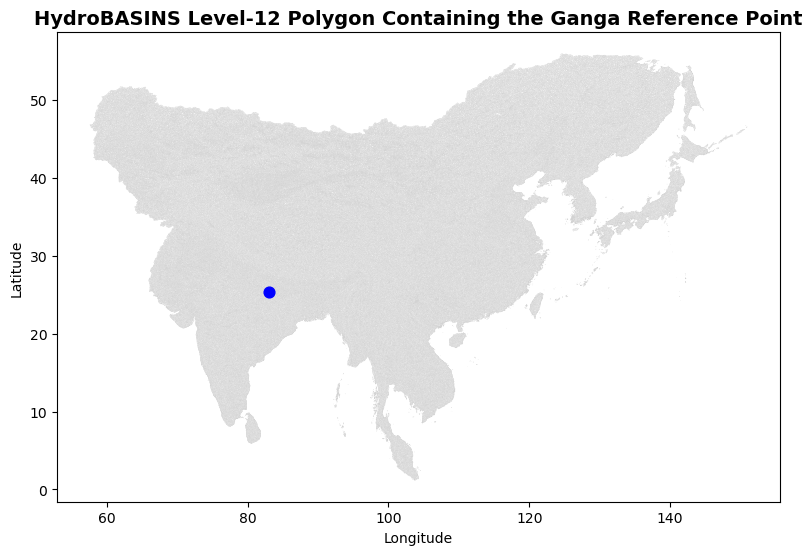

In [39]:
# ============================================================
# Visualize the Ganga Basin
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Plot all HydroBASINS polygons
basins.plot(
    ax=ax,
    facecolor="white",
    edgecolor="lightgray",
    linewidth=0.2
)

# Highlight the selected Ganga basin polygon
ganga_basin.plot(
    ax=ax,
    color="red",
    edgecolor="black"
)

# Plot the reference point
point.plot(
    ax=ax,
    color="blue",
    markersize=60,
    marker="o"
)

ax.set_title("HydroBASINS Level-12 Polygon Containing the Ganga Reference Point",
             fontsize=14,
             fontweight="bold")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [ ]:
Step 5 – Check the Basin ID

In [25]:
# ============================================================
# Display Selected Ganga Basin Attributes
# ============================================================

print(
    ganga_basin[
        [
            "HYBAS_ID",
            "PFAF_ID",
            "UP_AREA"
        ]
    ]
)

         HYBAS_ID       PFAF_ID   UP_AREA
74200  4120914230  452457030100  462110.8


In [ ]:
Part 4.4 – Find the Complete Cauvery Basin

In [ ]:
Step 1 – Load Level 5

In [26]:
# ============================================================
# Load HydroBASINS Level-5 Dataset
# (Suitable for extracting the entire Ganga Basin)
# ============================================================

basins5 = gpd.read_file(
    r"G:\OCR\hydroriver\hybas_as_lev01-12_v1c\hybas_as_lev05_v1c.shp"
)

print("✓ HydroBASINS Level-5 loaded successfully.")
print(f"Number of Level-5 basins: {len(basins5):,}")

✓ HydroBASINS Level-5 loaded successfully.
Number of Level-5 basins: 711


In [27]:
# ============================================================
# Check Coordinate Reference System (CRS)
# ============================================================

print("HydroBASINS Level-5 CRS:")
print(basins5.crs)

HydroBASINS Level-5 CRS:
EPSG:4326


In [37]:
# ============================================================
# Extract the Ganga Basin from HydroBASINS Level-5
# ============================================================

ganga5 = basins5[basins5.intersects(ganga_point)]

print("Number of matching Level-5 basins:", len(ganga5))

display(ganga5[["HYBAS_ID", "PFAF_ID", "UP_AREA"]])

Number of matching Level-5 basins: 1


,HYBAS_ID,PFAF_ID,UP_AREA
352,4050901960,45245,522571.8


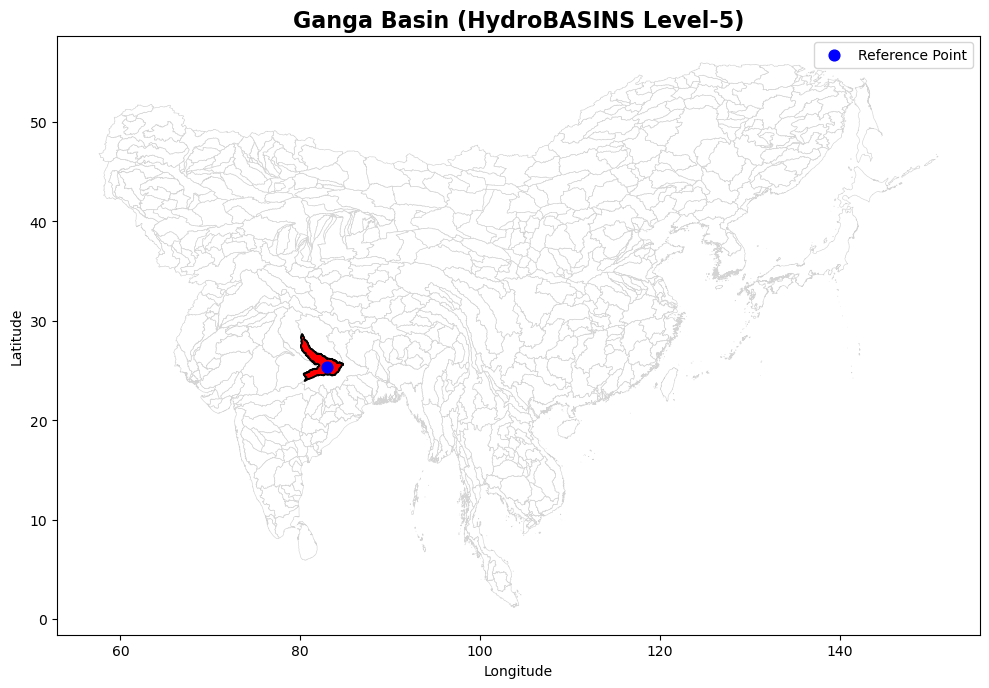

In [38]:
# ============================================================
# Visualize the Ganga Basin (HydroBASINS Level-5)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))

# Plot all Level-5 basins
basins5.plot(
    ax=ax,
    facecolor="white",
    edgecolor="lightgray",
    linewidth=0.4
)

# Highlight the selected Ganga Level-5 basin
ganga5.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=1.2,
    label="Ganga Basin (Level-5)"
)

# Plot the reference point
point.plot(
    ax=ax,
    color="blue",
    marker="o",
    markersize=60,
    label="Reference Point"
)

ax.set_title(
    "Ganga Basin (HydroBASINS Level-5)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend()

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# Ganga Basin Information (Level-5)
# ============================================================

display(
    ganga5[
        [
            "HYBAS_ID",
            "PFAF_ID",
            "UP_AREA",
            "SUB_AREA",
            "ORDER"
        ]
    ]
)

,HYBAS_ID,PFAF_ID,UP_AREA,SUB_AREA,ORDER
352,4050901960,45245,522571.8,82221.8,2


In [ ]:
Section 4.5 — Clip HydroRIVERS to the Cauvery Basin

In [41]:
# ============================================================
# Required Libraries for Basin Visualization
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
Section 4
Download Official Ganga Centerline
            │
            ▼
Load in GeoPandas
            │
            ▼
Merge into Single LineString
            │
            ▼
Create Sampling Points Every 10 km
            │
            ▼
Export Points (Shapefile/GeoJSON)
            │
            ▼
Upload to Google Earth Engine
            │
            ▼
Extract Landsat Images
            │
            ▼
Apply Aqua-OC
            │
            ▼
Estimate POC
            │
            ▼
Calculate POC Flux

Number of segments: 163483


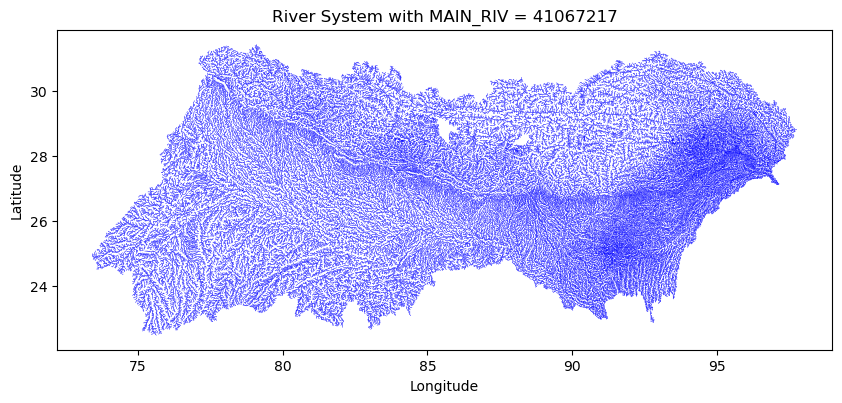

In [70]:
# Extract the entire river system using MAIN_RIV
ganga_system = rivers[rivers["MAIN_RIV"] == 41067217].copy()

print("Number of segments:", len(ganga_system))

fig, ax = plt.subplots(figsize=(10, 10))

ganga_system.plot(
    ax=ax,
    color="blue",
    linewidth=0.3
)

plt.title("River System with MAIN_RIV = 41067217")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [75]:
print(main_river["DIST_UP_KM"].describe())

count     111.000000
mean     1729.136036
std       138.312458
min      1493.400000
25%      1621.850000
50%      1715.000000
75%      1853.250000
max      1957.100000
Name: DIST_UP_KM, dtype: float64


In [76]:
print(main_river["DIST_DN_KM"].describe())

count     111.000000
mean     1106.058559
std       138.311963
min       878.100000
25%       981.900000
50%      1120.200000
75%      1213.350000
max      1341.700000
Name: DIST_DN_KM, dtype: float64


In [77]:
print(main_river.sort_values("DIST_UP_KM", ascending=False).head(20))

        HYRIV_ID  NEXT_DOWN  DIST_UP_KM  DIST_DN_KM  UPLAND_SKM  ORD_STRA  \
928574  40928575   40928330      1957.1       878.1    522571.8         8   
929482  40929483   40928575      1956.7       878.5    522500.0         8   
930707  40930708   40929483      1952.8       882.4    522481.6         8   
931224  40931225   40930708      1949.3       885.9    522463.4         8   
931688  40931689   40931225      1948.2       887.0    522328.5         8   
931966  40931967   40931689      1946.3       888.9    522273.7         8   
932893  40932894   40931967      1945.9       889.3    522255.2         8   
932892  40932893   40932894      1939.2       895.9    521493.9         8   
932891  40932892   40932893      1938.6       896.6    521475.7         8   
931686  40931687   40932892      1935.5       899.7    521164.0         8   
930705  40930706   40931687      1933.2       902.0    521146.6         8   
929479  40929480   40930706      1929.1       906.1    521114.1         8   

In [78]:
print("Network segments:", len(network))
print("Ganga rivers:", len(ganga_rivers))
print("Total rivers:", len(rivers))

Network segments: 3937
Ganga rivers: 3937
Total rivers: 1428959


In [79]:
import geopandas as gpd

network = gpd.read_file(
    r"G:\OCR\Ganga\Ganga_HydroRIVERS.shp"
)

print("Network segments:", len(network))
network.head()

Network segments: 50896


,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,geometry
0,40631851,40632133,41067217,5.30,2490.8,8.8,28.94,28.9,0,0.512,1,4,7,4120725680,"LINESTRING (79.10208 31.4375, 79.10208 31.4187..."
1,40631852,40632133,41067217,0.59,2490.7,4.6,8.06,8.1,0,0.150,1,5,7,4120725680,"LINESTRING (79.10417 31.39375, 79.09792 31.39375)"
2,40632132,40633088,41067217,2.38,2489.7,6.1,10.81,10.8,0,0.193,1,5,7,4120725680,"LINESTRING (79.08542 31.40417, 79.08542 31.397..."
3,40632133,40633088,41067217,1.07,2489.9,9.7,0.73,37.7,0,0.675,2,4,7,4120725680,"LINESTRING (79.09792 31.39375, 79.09792 31.389..."
4,40632800,40634211,41067217,2.08,2487.0,6.2,11.54,11.5,0,0.219,1,6,7,4120725690,"LINESTRING (79.13125 31.38333, 79.13125 31.36458)"


In [80]:
print(network.columns.tolist())

['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM', 'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS', 'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'geometry']


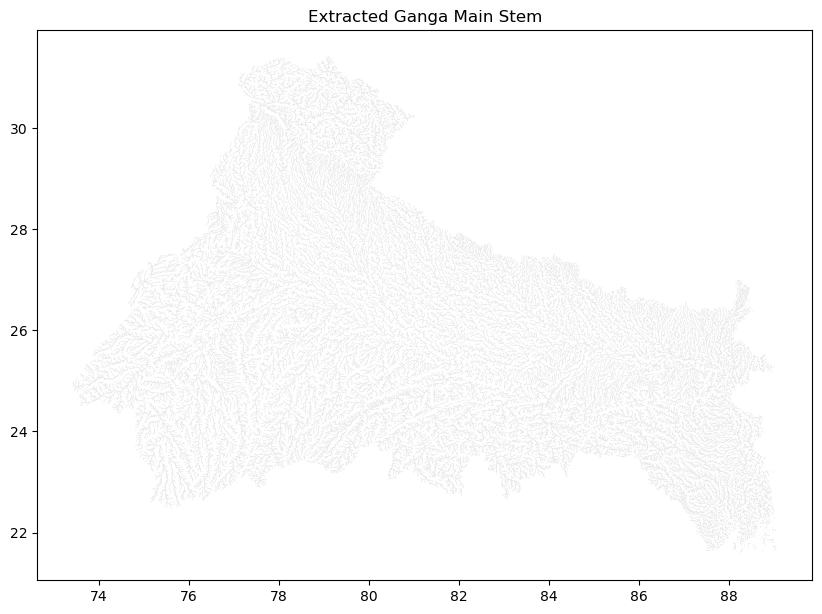

In [85]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

network.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2
)

main_river.plot(
    ax=ax,
    color="blue",
    linewidth=2
)

plt.title("Extracted Ganga Main Stem")
plt.show()

In [89]:
seed = network.loc[
    network["UPLAND_SKM"].idxmax()
]

print(seed)

HYRIV_ID                                               41014751
NEXT_DOWN                                              41014968
MAIN_RIV                                               41067217
LENGTH_KM                                                  8.56
DIST_DN_KM                                                262.7
DIST_UP_KM                                               2572.5
CATCH_SKM                                                 31.89
UPLAND_SKM                                             942435.1
ENDORHEIC                                                     0
DIS_AV_CMS                                            13500.322
ORD_STRA                                                      8
ORD_CLAS                                                      2
ORD_FLOW                                                      2
HYBAS_L12                                            4120948070
geometry      MULTILINESTRING ((88.71458333333285 24.3043539...
Name: 35783, dtype: object


In [90]:
main_ids = set()

current = int(seed["HYRIV_ID"])

while True:

    main_ids.add(current)

    row = network.loc[
        network["HYRIV_ID"] == current
    ]

    if row.empty:
        break

    next_down = int(row.iloc[0]["NEXT_DOWN"])

    if next_down == 0:
        break

    current = next_down

In [91]:
from collections import defaultdict

up_lookup = defaultdict(list)

for _, row in network.iterrows():
    up_lookup[int(row["NEXT_DOWN"])].append(int(row["HYRIV_ID"]))

In [92]:
current = int(seed["HYRIV_ID"])

while True:

    upstream = up_lookup.get(current, [])

    if len(upstream) == 0:
        break

    candidates = network[
        network["HYRIV_ID"].isin(upstream)
    ]

    current = int(
        candidates.sort_values(
            "UPLAND_SKM",
            ascending=False
        ).iloc[0]["HYRIV_ID"]
    )

    main_ids.add(current)

In [93]:
main_river = network[
    network["HYRIV_ID"].isin(main_ids)
].copy()

print("Main stem segments:", len(main_river))

Main stem segments: 12


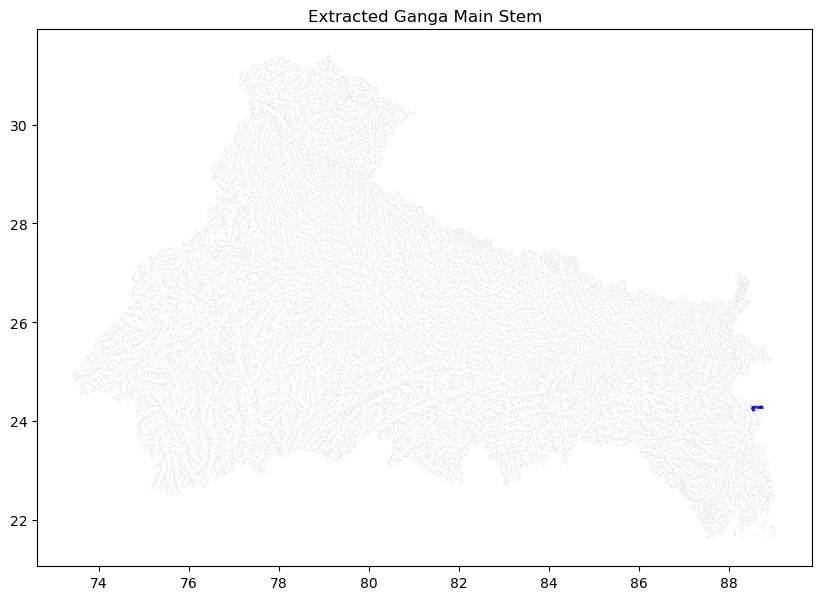

In [94]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

network.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2
)

main_river.plot(
    ax=ax,
    color="blue",
    linewidth=2
)

plt.title("Extracted Ganga Main Stem")
plt.show()

In [95]:
seed = network.loc[network["UPLAND_SKM"].idxmax()]

seed_id = int(seed["HYRIV_ID"])

print(seed)

print("\nSegments flowing into the seed:")

print(up_lookup.get(seed_id, []))

HYRIV_ID                                               41014751
NEXT_DOWN                                              41014968
MAIN_RIV                                               41067217
LENGTH_KM                                                  8.56
DIST_DN_KM                                                262.7
DIST_UP_KM                                               2572.5
CATCH_SKM                                                 31.89
UPLAND_SKM                                             942435.1
ENDORHEIC                                                     0
DIS_AV_CMS                                            13500.322
ORD_STRA                                                      8
ORD_CLAS                                                      2
ORD_FLOW                                                      2
HYBAS_L12                                            4120948070
geometry      MULTILINESTRING ((88.71458333333285 24.3043539...
Name: 35783, dtype: object

Segments flo

In [96]:
network[
    network["NEXT_DOWN"] == seed_id
][
    ["HYRIV_ID", "UPLAND_SKM", "DIST_UP_KM", "ORD_STRA"]
].sort_values("UPLAND_SKM", ascending=False)

,HYRIV_ID,UPLAND_SKM,DIST_UP_KM,ORD_STRA
35214,41011913,292.6,41.5,3


In [97]:
ganga = network[
    network["MAIN_RIV"] == 41067217
].copy()

print("Segments:", len(ganga))

Segments: 42934


In [98]:
from shapely.ops import unary_union, linemerge

In [99]:
merged = unary_union(ganga.geometry)

print(type(merged))

<class 'shapely.geometry.multilinestring.MultiLineString'>


In [100]:
centerline = linemerge(merged)

print(type(centerline))

<class 'shapely.geometry.multilinestring.MultiLineString'>


In [101]:
print(centerline.geom_type)

MultiLineString


In [102]:
from shapely.geometry import LineString, MultiLineString

if centerline.geom_type == "MultiLineString":

    print("Number of lines:", len(centerline.geoms))

    lengths = [line.length for line in centerline.geoms]

    print("Longest line length:", max(lengths))

Number of lines: 43244
Longest line length: 0.7086084049082693


In [ ]:
Automatic Ganga Centerline Extraction using Graph Theory
Objective

Convert the GRWL river network into a graph:

River segments
       │
       ▼
Nodes (segment endpoints)
       │
       ▼
Network Graph
       │
       ▼
Longest Connected Path
       │
       ▼
Verified Ganga Centerline
       │
       ▼
10 km Sampling Points

In [3]:
import geopandas as gpd

grwl = gpd.read_file(
    r"G:\OCR\GRWL\GRWL_Ganga.shp"
)

print("Segments:", len(grwl))
grwl.head()

Segments: 739


,OBJECTID,ID,width_min_,width_med_,width_mean,width_max_,width_sd_m,lakeFlag,nSegPx,Shape_Leng,geometry
0,6345,132,30,36.0,30.0,63,9.212770,0.0,78,2.497638,"LINESTRING (75.96648 23.99987, 75.967 23.99093..."
1,6347,155,30,42.0,50.0,84,11.946149,0.0,515,16.708361,"LINESTRING (75.79312 23.12863, 75.78971 23.121..."
2,6349,131,30,42.0,50.0,94,12.355750,0.0,710,22.575616,"LINESTRING (76.89423 23.19361, 76.89947 23.191..."
3,6350,86,30,42.0,50.0,199,16.881664,0.0,984,32.162493,"LINESTRING (75.79327 23.1289, 75.79708 23.1286..."
4,6353,185,30,42.0,50.0,84,12.557797,0.0,356,11.478414,"LINESTRING (77.84007 23.77369, 77.83684 23.774..."


In [4]:
import networkx as nx

In [5]:
import networkx as nx

G = nx.Graph()

for idx, row in grwl.iterrows():

    geom = row.geometry

    if geom.geom_type == "LineString":

        coords = list(geom.coords)

        start = coords[0]
        end = coords[-1]

        G.add_edge(
            start,
            end,
            geometry=geom,
            length=geom.length
        )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1392
Edges: 696


In [6]:
components = list(nx.connected_components(G))

print("Connected components:", len(components))

Connected components: 696


In [7]:
sizes = sorted(
    [len(c) for c in components],
    reverse=True
)

print(sizes[:20])

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [8]:
print(grwl.geom_type.value_counts())

LineString         696
MultiLineString     43
Name: count, dtype: int64


In [9]:
print(grwl.crs)

EPSG:4326


In [10]:
print(grwl.columns.tolist())

['OBJECTID', 'ID', 'width_min_', 'width_med_', 'width_mean', 'width_max_', 'width_sd_m', 'lakeFlag', 'nSegPx', 'Shape_Leng', 'geometry']


In [11]:
geom = grwl.geometry.iloc[0]

print(geom.geom_type)

print(list(geom.coords)[:5])

LineString
[(75.9664800003518, 23.999870000100486), (75.96700000005, 23.99092999971975), (75.97007999999204, 23.988199999730227), (75.97301999977321, 23.987639999986072), (75.97621999985319, 23.981390000448187)]


In [12]:
from shapely.geometry import Point
import geopandas as gpd

points = []

for geom in grwl.geometry:

    if geom.geom_type == "LineString":

        coords = list(geom.coords)

        points.append(Point(coords[0]))
        points.append(Point(coords[-1]))

    elif geom.geom_type == "MultiLineString":

        for line in geom.geoms:

            coords = list(line.coords)

            points.append(Point(coords[0]))
            points.append(Point(coords[-1]))

endpoints = gpd.GeoDataFrame(
    geometry=points,
    crs=grwl.crs
)

print("Endpoint count:", len(endpoints))

Endpoint count: 2108


In [13]:
endpoints_m = endpoints.to_crs(3857)

In [14]:
from scipy.spatial import cKDTree
import numpy as np

coords = np.array(
    [(p.x, p.y) for p in endpoints_m.geometry]
)

tree = cKDTree(coords)

dist, idx = tree.query(coords, k=2)

nearest = dist[:,1]

print(nearest.min())
print(np.percentile(nearest,25))
print(np.median(nearest))
print(np.percentile(nearest,75))
print(nearest.max())

0.5162786994865014
33.17442475585267
51.95000401494144
776.8117017103713
60165.45354214167


In [15]:
import geopandas as gpd

ganga = gpd.read_file(
    r"G:\OCR\GANGA\ganag_mainstream.shp"
)

print(ganga.crs)
print(ganga.length)

EPSG:4326
0    22.559467
dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_12304\2509315786.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(ganga.length)


In [16]:
ganga_m = ganga.to_crs(3395)

In [17]:
length = ganga_m.length.iloc[0]

print(f"River length = {length/1000:.2f} km")

River length = 2636.59 km


In [18]:
from shapely.geometry import Point
import numpy as np

line = ganga_m.geometry.iloc[0]

spacing = 50000  # 50 km

distances = np.arange(0, line.length + spacing, spacing)

points = [line.interpolate(d) for d in distances]

points = gpd.GeoDataFrame(
    {"Distance_km": distances / 1000},
    geometry=points,
    crs=ganga_m.crs
)

print(points.head())
print("Total sampling points:", len(points))

   Distance_km                         geometry
0          0.0  POINT (8736948.084 3527835.782)
1         50.0  POINT (8747759.887 3494701.584)
2        100.0  POINT (8726262.776 3497629.353)
3        150.0  POINT (8700465.238 3466901.664)
4        200.0   POINT (8690120.65 3427775.194)
Total sampling points: 54


In [19]:
points_wgs = points.to_crs(4326)

In [22]:
points_wgs.to_file(
    r"G:\OCR\GANGA\Ganga_50km_points.shp"
)

points_wgs.to_file(
    r"G:\OCR\GANGA\Ganga_50km_points.geojson",
    driver="GeoJSON"
)

points_wgs.drop(columns="geometry").to_csv(
    r"G:\OCR\GANGA\Ganga_50km_points.csv",
    index=False
)

In [23]:
points_wgs.rename(
    columns={"Distance_km": "Dist_km"},
    inplace=True
)

In [24]:
# ============================================================
# Module 5 | Lesson 18
# Import Required Python Libraries
# ============================================================

import ee
import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
# ============================================================
# Initialize Google Earth Engine
# ============================================================

# Authenticate only once if required
# ee.Authenticate()

# Initialize the Earth Engine project
ee.Initialize(project="oc-flux")

print("Google Earth Engine Initialized Successfully")

Google Earth Engine Initialized Successfully


In [26]:
# ============================================================
# Create Interactive Map
# ============================================================

Map = geemap.Map()

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [27]:
# ============================================================
# Read Ganga 50 km Sampling Points
# ============================================================

points = gpd.read_file(
    r"G:\OCR\GANGA\Ganga_50km_points.shp"
)

print("Coordinate Reference System")
print(points.crs)

print()

print("Number of Sampling Points")
print(len(points))

points.head()

Coordinate Reference System
EPSG:4326

Number of Sampling Points
54


,Dist_km,geometry
0,0.0,POINT (78.48534 30.35626)
1,50.0,POINT (78.58246 30.09779)
2,100.0,POINT (78.38935 30.12065)
3,150.0,POINT (78.15761 29.8804)
4,200.0,POINT (78.06468 29.57362)


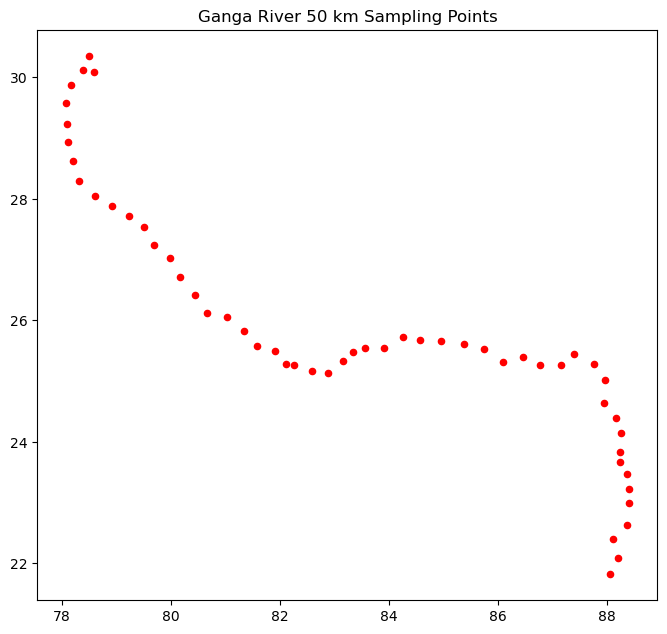

In [28]:
# ============================================================
# Plot the Sampling Points
# ============================================================

fig, ax = plt.subplots(figsize=(8,12))

points.plot(
    ax=ax,
    color="red",
    markersize=20
)

plt.title("Ganga River 50 km Sampling Points")

plt.show()

In [29]:
# ============================================================
# Display Sampling Points on Interactive Map
# ============================================================

Map = geemap.Map()

Map.add_gdf(
    points,
    layer_name="Ganga 50 km Points"
)

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [30]:
# ============================================================
# Convert GeoDataFrame to Earth Engine FeatureCollection
# ============================================================

ee_points = geemap.geopandas_to_ee(points)

print(ee_points)

ee.FeatureCollection({
  "functionInvocationValue": {
    "functionName": "Collection",
    "arguments": {
      "features": {
        "arrayValue": {
          "values": [
            {
              "functionInvocationValue": {
                "functionName": "Feature",
                "arguments": {
                  "geometry": {
                    "functionInvocationValue": {
                      "functionName": "GeometryConstructors.Point",
                      "arguments": {
                        "coordinates": {
                          "constantValue": [
                            78.4853399999411,
                            30.35625999969927
                          ]
                        }
                      }
                    }
                  },
                  "metadata": {
                    "constantValue": {
                      "Dist_km": 0.0
                    }
                  }
                }
              }
            },
            

In [31]:
# ============================================================
# Display the FeatureCollection
# ============================================================

Map = geemap.Map()

Map.addLayer(
    ee_points,
    {"color":"red"},
    "Sampling Points"
)

Map.centerObject(
    ee_points,
    6
)

Map

Map(center=[25.972569705839373, 83.473214287987], controls=(WidgetControl(options=['position', 'transparent_bg…

In [32]:
# ============================================================
# Count the Number of Features
# ============================================================

print(
    "Total Sampling Points:",
    ee_points.size().getInfo()
)

Total Sampling Points: 54


In [33]:
# ============================================================
# Module 5 | Lesson 19
# Landsat Surface Reflectance Preprocessing
# ============================================================

import ee
import geemap
import geopandas as gpd

# Initialize Earth Engine
ee.Initialize(project="oc-flux")

print("Google Earth Engine Initialized Successfully")

Google Earth Engine Initialized Successfully


In [34]:
# ============================================================
# Load Ganga Sampling Points
# ============================================================

points = gpd.read_file(
    r"G:\OCR\GANGA\Ganga_50km_points.shp"
)

print("Number of Sampling Points:", len(points))
points.head()

Number of Sampling Points: 54


,Dist_km,geometry
0,0.0,POINT (78.48534 30.35626)
1,50.0,POINT (78.58246 30.09779)
2,100.0,POINT (78.38935 30.12065)
3,150.0,POINT (78.15761 29.8804)
4,200.0,POINT (78.06468 29.57362)


In [35]:
# ============================================================
# Convert GeoDataFrame to Earth Engine
# ============================================================

ee_points = geemap.geopandas_to_ee(points)

print("Earth Engine FeatureCollection Created")

Earth Engine FeatureCollection Created


In [36]:
# ============================================================
# Create a 5 km Buffer Around Sampling Points
# ============================================================

buffer = ee_points.map(
    lambda f: f.buffer(5000)
)

study_area = buffer.geometry()

print("Study Area Created")

Study Area Created


In [37]:
# ============================================================
# Load Landsat 8 Collection 2 Level 2
# ============================================================

landsat8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(study_area)
    .filterDate("2023-01-01", "2023-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER",20))
)

print(
    "Number of Landsat Images:",
    landsat8.size().getInfo()
)

Number of Landsat Images: 231


In [38]:
# ============================================================
# Load Landsat 9 Collection
# ============================================================

landsat9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(study_area)
    .filterDate("2023-01-01","2023-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER",20))
)

print(
    "Number of Landsat 9 Images:",
    landsat9.size().getInfo()
)

Number of Landsat 9 Images: 223


In [39]:
# ============================================================
# Merge Landsat 8 and Landsat 9
# ============================================================

landsat = landsat8.merge(landsat9)

print(
    "Total Images:",
    landsat.size().getInfo()
)

Total Images: 454


In [40]:
# ============================================================
# Cloud Mask Function
# Landsat Collection 2 Level 2
# ============================================================

def maskLandsat(image):

    qa = image.select("QA_PIXEL")

    mask = (
        qa.bitwiseAnd(1 << 3).eq(0)  # Cloud
        .And(qa.bitwiseAnd(1 << 4).eq(0))  # Cloud Shadow
        .And(qa.bitwiseAnd(1 << 2).eq(0))  # Cirrus
    )

    optical = (
        image.select([
            "SR_B1",
            "SR_B2",
            "SR_B3",
            "SR_B4",
            "SR_B5",
            "SR_B6",
            "SR_B7"
        ])
        .multiply(0.0000275)
        .add(-0.2)
    )

    return optical.updateMask(mask)

In [41]:
# ============================================================
# Apply Cloud Mask
# ============================================================

landsat_clean = landsat.map(maskLandsat)

print("Cloud Mask Applied")

Cloud Mask Applied


In [42]:
# ============================================================
# Create Median Composite
# ============================================================

composite = (
    landsat_clean
    .median()
    .clip(study_area)
)

print("Median Composite Created")

Median Composite Created


In [43]:
# ============================================================
# Display RGB Image
# ============================================================

Map = geemap.Map()

rgb = {
    "bands":["SR_B4","SR_B3","SR_B2"],
    "min":0,
    "max":0.30
}

Map.addLayer(
    composite,
    rgb,
    "Landsat RGB"
)

Map.addLayer(
    ee_points,
    {"color":"red"},
    "Sampling Points"
)

Map.centerObject(
    ee_points,
    6
)

Map

Map(center=[25.972569705839373, 83.473214287987], controls=(WidgetControl(options=['position', 'transparent_bg…

In [44]:
# ============================================================
# Check Available Bands
# ============================================================

print(
    composite.bandNames().getInfo()
)

['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']


In [45]:
# ============================================================
# Section 8
# Load Landsat 8 & 9 Surface Reflectance Collection
# ============================================================

# Load Landsat 8 Collection 2 Level-2
landsat8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(study_area)
    .filterDate("2023-01-01", "2023-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER", 20))
)

# Load Landsat 9 Collection 2 Level-2
landsat9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(study_area)
    .filterDate("2023-01-01", "2023-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER", 20))
)

# Merge the two collections
landsat = landsat8.merge(landsat9)

print("Total Landsat Images:", landsat.size().getInfo())

Total Landsat Images: 454


In [47]:
# ============================================================
# Section 9
# Cloud Mask Function for Landsat Collection 2 Level-2
# ============================================================

def mask_landsat(image):
    """
    Removes clouds and cloud shadows from Landsat Collection 2
    and converts digital numbers to surface reflectance.
    """

    # QA_PIXEL band
    qa = image.select("QA_PIXEL")

    # Bit masks
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloud_shadow = qa.bitwiseAnd(1 << 4).eq(0)
    cirrus = qa.bitwiseAnd(1 << 2).eq(0)

    # Combined mask
    mask = cloud.And(cloud_shadow).And(cirrus)

    # Scale optical bands to surface reflectance
    optical = (
        image.select([
            "SR_B1",
            "SR_B2",
            "SR_B3",
            "SR_B4",
            "SR_B5",
            "SR_B6",
            "SR_B7"
        ])
        .multiply(0.0000275)
        .add(-0.2)
    )

    return optical.updateMask(mask)

In [48]:
# Create a cloud-free median composite
composite = (
    landsat
    .map(mask_landsat)
    .median()
    .clip(study_area)
)

print("Cloud-free composite created successfully.")# ============================================================
# Section 9
# Cloud Mask Function for Landsat Collection 2 Level-2
# ============================================================

def mask_landsat(image):
    """
    Removes clouds and cloud shadows from Landsat Collection 2
    and converts digital numbers to surface reflectance.
    """

    # QA_PIXEL band
    qa = image.select("QA_PIXEL")

    # Bit masks
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloud_shadow = qa.bitwiseAnd(1 << 4).eq(0)
    cirrus = qa.bitwiseAnd(1 << 2).eq(0)

    # Combined mask
    mask = cloud.And(cloud_shadow).And(cirrus)

    # Scale optical bands to surface reflectance
    optical = (
        image.select([
            "SR_B1",
            "SR_B2",
            "SR_B3",
            "SR_B4",
            "SR_B5",
            "SR_B6",
            "SR_B7"
        ])
        .multiply(0.0000275)
        .add(-0.2)
    )

    return optical.updateMask(mask)

Cloud-free composite created successfully.


In [49]:
Map = geemap.Map()

rgb = {
    "bands": ["SR_B4", "SR_B3", "SR_B2"],
    "min": 0,
    "max": 0.30
}

Map.addLayer(
    composite,
    rgb,
    "Landsat RGB Composite"
)

Map.addLayer(
    ee_points,
    {"color": "red"},
    "Sampling Points"
)

Map.centerObject(ee_points, 6)

Map

Map(center=[25.972569705839373, 83.473214287987], controls=(WidgetControl(options=['position', 'transparent_bg…

In [50]:
reflectance = composite.sampleRegions(

    collection=ee_points,

    scale=30,

    geometries=True

)

print("Reflectance extracted successfully.")

Reflectance extracted successfully.


In [55]:
# ============================================================
# Convert Earth Engine FeatureCollection to Pandas DataFrame
# Compatible with pandas 3.x
# ============================================================

import pandas as pd

# Download FeatureCollection as a Python dictionary
features = reflectance.getInfo()["features"]

# Extract only the attribute table
records = [feature["properties"] for feature in features]

# Create DataFrame
df = pd.DataFrame(records)

print(df.head())
print()
print("Number of observations:", len(df))

   Dist_km     SR_B1     SR_B2     SR_B3     SR_B4     SR_B5     SR_B6  \
0        0  0.027164  0.035840  0.051034  0.035111  0.076471  0.058005   
1       50  0.034685  0.052340  0.080995  0.056767  0.050387  0.038288   
2      100  0.038425  0.053261  0.079441  0.057304  0.041794  0.022516   
3      150  0.050910  0.056520  0.080005  0.077943  0.218303  0.227350   
4      200  0.071906  0.088090  0.128034  0.138759  0.224133  0.253929   

      SR_B7  
0  0.027356  
1  0.026078  
2  0.016425  
3  0.144410  
4  0.176076  

Number of observations: 54


In [56]:
print(df.columns.tolist())

['Dist_km', 'SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']


In [57]:
# ============================================================
# Section 19
# Inspect the Reflectance Dataset
# ============================================================

print(df.head())

print()

print(df.columns.tolist())

   Dist_km     SR_B1     SR_B2     SR_B3     SR_B4     SR_B5     SR_B6  \
0        0  0.027164  0.035840  0.051034  0.035111  0.076471  0.058005   
1       50  0.034685  0.052340  0.080995  0.056767  0.050387  0.038288   
2      100  0.038425  0.053261  0.079441  0.057304  0.041794  0.022516   
3      150  0.050910  0.056520  0.080005  0.077943  0.218303  0.227350   
4      200  0.071906  0.088090  0.128034  0.138759  0.224133  0.253929   

      SR_B7  
0  0.027356  
1  0.026078  
2  0.016425  
3  0.144410  
4  0.176076  

['Dist_km', 'SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']


In [58]:
# ============================================================
# Section 20
# Check Missing Values
# ============================================================

print(df.isnull().sum())

Dist_km    0
SR_B1      0
SR_B2      0
SR_B3      0
SR_B4      0
SR_B5      0
SR_B6      0
SR_B7      0
dtype: int64


In [59]:
# ============================================================
# Section 21
# Create Aqua-OC Input Dataset
# ============================================================

spectral_columns = [

    "SR_B1",
    "SR_B2",
    "SR_B3",
    "SR_B4",
    "SR_B5",
    "SR_B6",
    "SR_B7"

]

aqua_input = df[spectral_columns].copy()

aqua_input.head()

,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
0,0.027164,0.035840,0.051034,0.035111,0.076471,0.058005,0.027356
1,0.034685,0.052340,0.080995,0.056767,0.050387,0.038288,0.026078
2,0.038425,0.053261,0.079441,0.057304,0.041794,0.022516,0.016425
3,0.050910,0.056520,0.080005,0.077943,0.218303,0.227350,0.144410
4,0.071906,0.088090,0.128034,0.138759,0.224133,0.253929,0.176076


In [60]:
# ============================================================
# Section 22
# Rename Landsat Bands
# ============================================================

aqua_input.columns = [

    "Coastal",

    "Blue",

    "Green",

    "Red",

    "NIR",

    "SWIR1",

    "SWIR2"

]

aqua_input.head()

,Coastal,Blue,Green,Red,NIR,SWIR1,SWIR2
0,0.027164,0.035840,0.051034,0.035111,0.076471,0.058005,0.027356
1,0.034685,0.052340,0.080995,0.056767,0.050387,0.038288,0.026078
2,0.038425,0.053261,0.079441,0.057304,0.041794,0.022516,0.016425
3,0.050910,0.056520,0.080005,0.077943,0.218303,0.227350,0.144410
4,0.071906,0.088090,0.128034,0.138759,0.224133,0.253929,0.176076


In [61]:
# ============================================================
# Section 23
# Summary Statistics
# ============================================================

aqua_input.describe()

,Coastal,Blue,Green,Red,NIR,SWIR1,SWIR2
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.058835,0.074843,0.112079,0.106998,0.139833,0.120475,0.095209
std,0.030089,0.033086,0.039526,0.052966,0.094219,0.119879,0.108119
min,0.023974,0.035290,0.051034,0.035111,0.041794,0.020852,0.013207
25%,0.039597,0.054781,0.086296,0.071961,0.062357,0.030388,0.019464
50%,0.050277,0.063911,0.101269,0.092215,0.080521,0.047445,0.033145
75%,0.061931,0.083508,0.123352,0.118134,0.232111,0.210534,0.144162
max,0.163000,0.189868,0.243080,0.271955,0.319337,0.388995,0.374612


In [62]:
# ============================================================
# Section 24
# Export Aqua-OC Input Dataset
# ============================================================

output = r"G:\OCR\GANGA\AquaOC_Input.csv"

aqua_input.to_csv(
    output,
    index=False
)

print("Saved Successfully")

print(output)

Saved Successfully
G:\OCR\GANGA\AquaOC_Input.csv


In [51]:
print("Selected MAIN_RIV:", main_river_id)

Selected MAIN_RIV: 41067217


In [52]:
print("Total clipped river segments:", len(ganga_rivers))
print("Main river segments:", len(main_river))

Total clipped river segments: 3937
Main river segments: 3937


In [53]:
print(main_river["MAIN_RIV"].value_counts())

MAIN_RIV
41067217    3937
Name: count, dtype: int64


In [54]:
# ============================================================
# Examine Strahler River Orders
# ============================================================

print("Maximum Strahler Order:", ganga_rivers["ORD_STRA"].max())

print("\nStrahler Order Distribution:\n")
print(ganga_rivers["ORD_STRA"].value_counts().sort_index())

Maximum Strahler Order: 8

Strahler Order Distribution:

ORD_STRA
1    1980
2     836
3     577
4     275
5     136
6      21
7       1
8     111
Name: count, dtype: int64


In [ ]:
Cell 5 – Save

In [54]:
main_river.to_file(
    r"G:\OCR\hydroriver\Main_Cauvery.shp"
)

In [ ]:
Section 4.7 – Identify the Main Stem Using Stream Order

In [55]:
print(cauvery_rivers["ORD_STRA"].value_counts().sort_index())

ORD_STRA
1    2302
2    1092
3     518
4     334
5     166
6     137
Name: count, dtype: int64


In [56]:
print("Maximum Stream Order:")

print(cauvery_rivers["ORD_STRA"].max())

Maximum Stream Order:
6


In [57]:
highest_order = cauvery_rivers["ORD_STRA"].max()

main_stem = cauvery_rivers[
    cauvery_rivers["ORD_STRA"] == highest_order
]

print(main_stem.shape)

(137, 15)


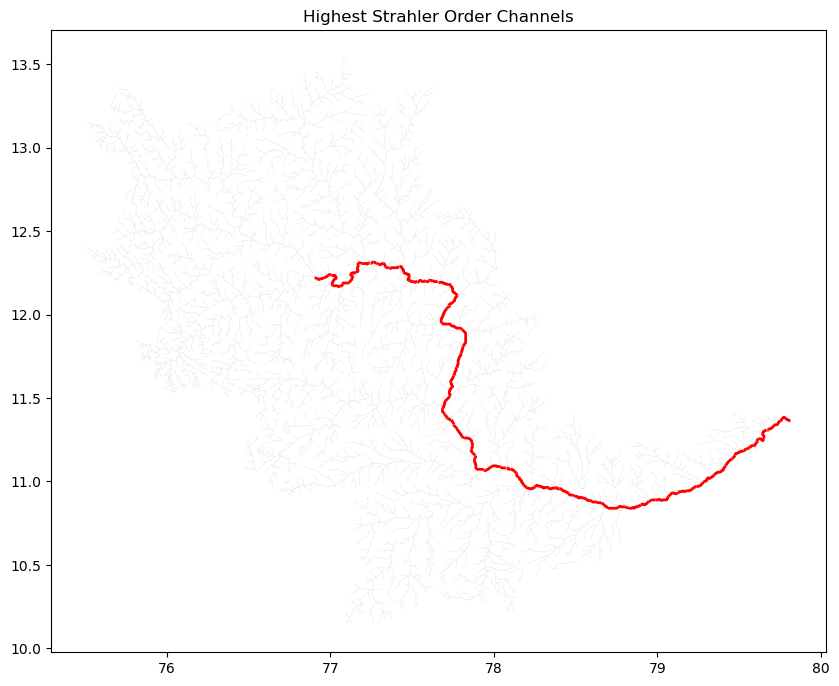

In [58]:
fig, ax = plt.subplots(figsize=(10,10))

cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2
)

main_stem.plot(
    ax=ax,
    color="red",
    linewidth=2
)

plt.title("Highest Strahler Order Channels")
plt.show()

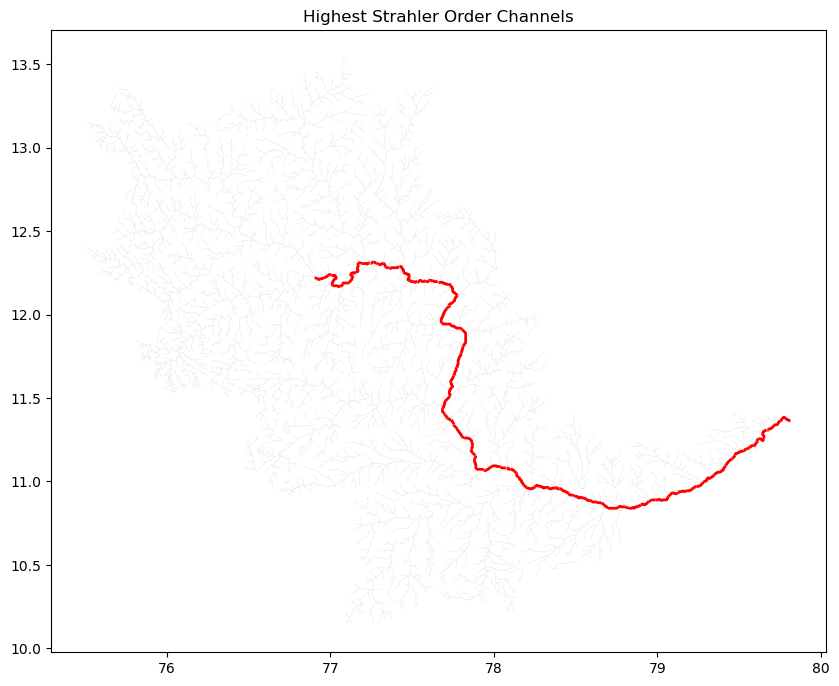

In [59]:
fig, ax = plt.subplots(figsize=(10,10))

cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2
)

main_stem.plot(
    ax=ax,
    color="red",
    linewidth=2
)

plt.title("Highest Strahler Order Channels")
plt.show()

In [60]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cauvery_rivers = gpd.read_file(
    r"G:\OCR\hydroriver\Cauvery_Rivers.shp"
)

print("River Segments:", len(cauvery_rivers))

River Segments: 4549


In [61]:
cauvery_rivers[[
    "HYRIV_ID",
    "NEXT_DOWN",
    "LENGTH_KM",
    "ORD_STRA",
    "DIS_AV_CMS"
]].head(20)

,HYRIV_ID,NEXT_DOWN,LENGTH_KM,ORD_STRA,DIS_AV_CMS
0,41388960,41388439,9.78,1,0.521
1,41388794,41388439,5.89,1,0.310
2,41388698,41388469,5.86,1,0.277
3,41388929,41388891,0.97,1,0.140
4,41388892,41388891,0.68,1,0.132
5,41388891,41388758,2.23,2,0.321
6,41388758,41388697,1.11,2,1.018
7,41388928,41388758,3.83,1,0.600
8,41388696,41388697,5.78,1,0.445
9,41388984,41388345,10.43,1,0.647


In [62]:
duplicates = cauvery_rivers["HYRIV_ID"].duplicated().sum()

print("Duplicate HYRIV_ID:", duplicates)

Duplicate HYRIV_ID: 0


In [ ]:
Section 41.4 – Find the Outlet

In [63]:
river_ids = set(cauvery_rivers["HYRIV_ID"])

outlets = cauvery_rivers[
    ~cauvery_rivers["NEXT_DOWN"].isin(river_ids)
]

print("Outlet segments:", len(outlets))

outlets[[
    "HYRIV_ID",
    "NEXT_DOWN",
    "ORD_STRA",
    "DIS_AV_CMS",
    "LENGTH_KM"
]]

Outlet segments: 1


,HYRIV_ID,NEXT_DOWN,ORD_STRA,DIS_AV_CMS,LENGTH_KM
41,41376077,0,6,307.501,9.03


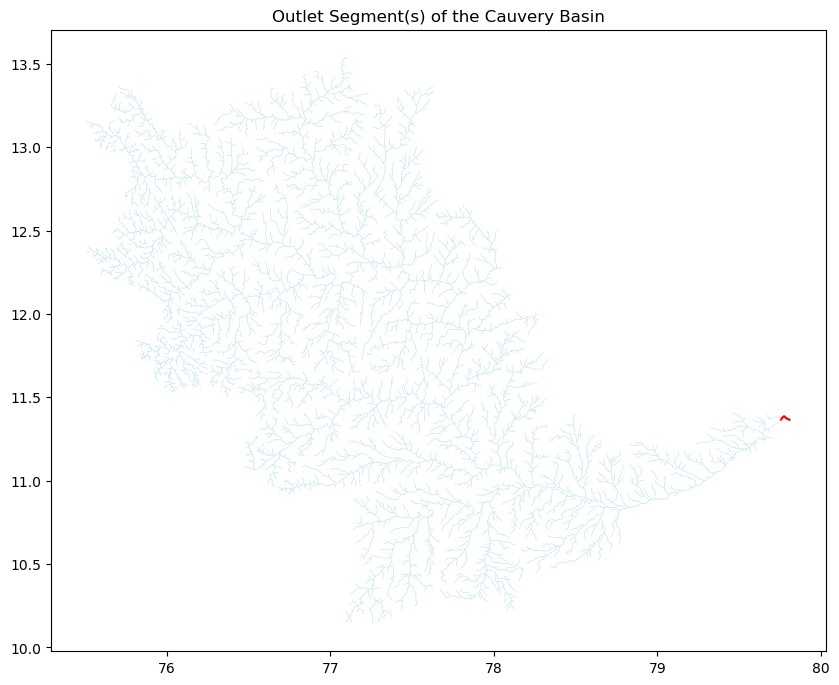

In [64]:
fig, ax = plt.subplots(figsize=(10,10))

cauvery_rivers.plot(
    ax=ax,
    color="lightblue",
    linewidth=0.3
)

outlets.plot(
    ax=ax,
    color="red",
    markersize=60
)

plt.title("Outlet Segment(s) of the Cauvery Basin")
plt.show()

In [ ]:
Section 41.6 – Build the River Connectivity Index

In [65]:
# Dictionary:
# key = downstream segment
# value = list of upstream segments

upstream = {}

for _, row in cauvery_rivers.iterrows():

    nxt = row["NEXT_DOWN"]

    hyriv = row["HYRIV_ID"]

    if nxt not in upstream:
        upstream[nxt] = []

    upstream[nxt].append(hyriv)

print("Dictionary created.")

print("Unique downstream IDs:", len(upstream))

Dictionary created.
Unique downstream IDs: 2248


In [66]:
count = 0

for k, v in upstream.items():

    print(k, " <-- ", v[:5])

    count += 1

    if count == 10:
        break

41388439  <--  [41388960, 41388794, 41388469]
41388469  <--  [41388698, 41388470]
41388891  <--  [41388929, 41388892]
41388758  <--  [41388891, 41388928]
41388697  <--  [41388758, 41388696]
41388345  <--  [41388984, 41388438]
41388437  <--  [41388697, 41388436]
41388344  <--  [41388568, 41388468]
41388216  <--  [41388437, 41388344]
41388178  <--  [41388216, 41388177]


In [67]:
outlet_id = 41376077

print("Segments flowing into the outlet:")

print(upstream[outlet_id])

Segments flowing into the outlet:
[41376732, 41376076]


In [68]:
branches = cauvery_rivers[
    cauvery_rivers["HYRIV_ID"].isin([41376732, 41376076])
]

branches[[
    "HYRIV_ID",
    "UPLAND_SKM",
    "DIS_AV_CMS",
    "ORD_STRA",
    "LENGTH_KM",
    "DIST_UP_KM",
    "DIST_DN_KM"
]]

,HYRIV_ID,UPLAND_SKM,DIS_AV_CMS,ORD_STRA,LENGTH_KM,DIST_UP_KM,DIST_DN_KM
40,41376732,78276.1,306.137,6,10.97,841.3,9.4
42,41376076,49.2,0.714,1,12.43,17.5,9.3


In [69]:
# Create a lookup dictionary by HYRIV_ID
river_lookup = cauvery_rivers.set_index("HYRIV_ID")

In [70]:
main_stem_ids = []

current = 41376077   # Outlet segment

while True:

    # Save current segment
    main_stem_ids.append(current)

    # Stop if no upstream segments
    if current not in upstream:
        break

    upstream_segments = upstream[current]

    # If only one upstream segment, continue
    if len(upstream_segments) == 1:
        current = upstream_segments[0]
        continue

    # If multiple upstream segments,
    # choose the one with the largest upstream area
    best = max(
        upstream_segments,
        key=lambda x: river_lookup.loc[x, "UPLAND_SKM"]
    )

    current = best

print("Main stem segments:", len(main_stem_ids))

Main stem segments: 207


In [71]:
main_stem = cauvery_rivers[
    cauvery_rivers["HYRIV_ID"].isin(main_stem_ids)
].copy()

print(main_stem.shape)

(207, 15)


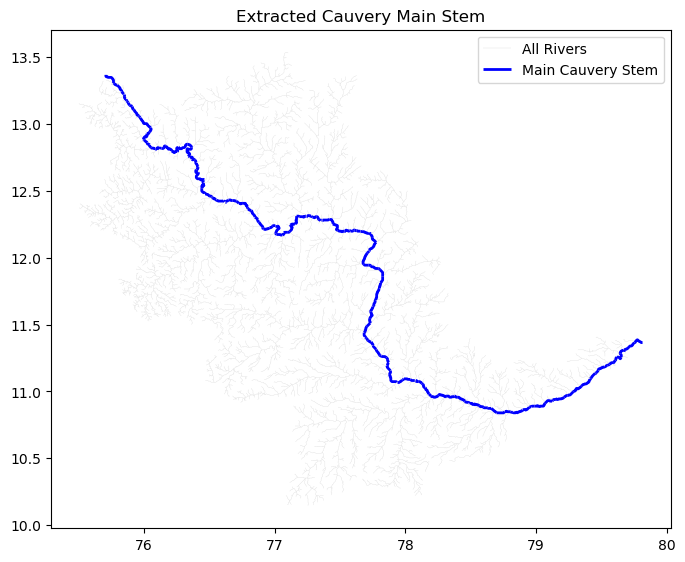

In [72]:
fig, ax = plt.subplots(figsize=(8, 12))

# Entire river network
cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2,
    label="All Rivers"
)

# Main stem
main_stem.plot(
    ax=ax,
    color="blue",
    linewidth=2,
    label="Main Cauvery Stem"
)

plt.legend()
plt.title("Extracted Cauvery Main Stem")
plt.show()

In [ ]:
SECTION 9 – Merge the Main Stem into One Continuous River

In [ ]:
SECTION 9.1 – Import Required Function

In [73]:
# =====================================================
# SECTION 9.1 – Import Merge Function
# =====================================================

from shapely.ops import linemerge
from shapely.geometry import MultiLineString
from shapely.geometry import LineString

In [ ]:
SECTION 9.2 – Sort the River Correctly

In [74]:
# =====================================================
# SECTION 9.2 – Sort Main Stem
# =====================================================

main_stem = main_stem.sort_values(
    "DIST_DN_KM",
    ascending=False
).reset_index(drop=True)

main_stem.head()

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,geometry
0,41343498,41343589,41376077,11.42,826.7,13.9,48.24,48.2,0,0.896,1,2,7,4121131440,"LINESTRING (75.71042 13.36667, 75.71042 13.356..."
1,41343589,41343834,41376077,0.65,826.2,14.3,0.42,73.3,0,1.402,2,2,6,4121131440,"LINESTRING (75.76875 13.30625, 75.77292 13.30208)"
2,41343834,41344593,41376077,3.29,822.8,17.8,6.68,96.5,0,1.793,3,2,6,4121131440,"LINESTRING (75.77292 13.30208, 75.78125 13.293..."
3,41344593,41344987,41376077,6.56,816.2,24.4,23.40,160.8,0,2.687,3,2,6,4121131440,"LINESTRING (75.79792 13.28958, 75.81875 13.268..."
4,41344987,41345234,41376077,3.05,813.3,27.2,3.13,190.1,0,3.022,3,2,6,4121131440,"LINESTRING (75.83125 13.24375, 75.83542 13.239..."


In [ ]:
SECTION 9.3 – Check Geometry Type

In [75]:
# =====================================================
# SECTION 9.3 – Check Geometry
# =====================================================

print(main_stem.geometry.iloc[0])

print(type(main_stem.geometry.iloc[0]))

LINESTRING (75.71041666666636 13.366666666666468, 75.71041666666636 13.356249999999768, 75.71458333333302 13.352083333333162, 75.72291666666635 13.352083333333162, 75.72708333333301 13.347916666666457, 75.75208333333305 13.347916666666457, 75.76458333333309 13.33541666666644, 75.76458333333309 13.331249999999777, 75.76874999999976 13.327083333333128, 75.76874999999976 13.306249999999785)
<class 'shapely.geometry.linestring.LineString'>


In [ ]:
SECTION 9.4 – Merge All Segments

In [76]:
# =====================================================
# SECTION 9.4 – Merge River Segments
# =====================================================

river_line = linemerge(main_stem.geometry.tolist())

print(type(river_line))

<class 'shapely.geometry.linestring.LineString'>


In [3]:
SECTION 9.5 – Handle MultiLineString

SyntaxError: invalid character '–' (U+2013) (3584230333.py, line 1)

In [77]:
# =====================================================
# SECTION 9.5 – Convert MultiLineString
# =====================================================

if isinstance(river_line, MultiLineString):

    print("River is MultiLineString.")

    river_line = linemerge(river_line)

else:

    print("River is already a LineString.")

print(type(river_line))

River is already a LineString.
<class 'shapely.geometry.linestring.LineString'>


In [ ]:
SECTION 9.6 – Plot the River

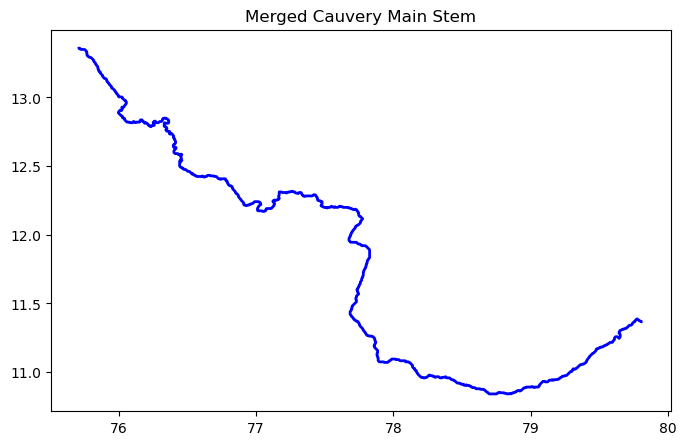

In [78]:
# =====================================================
# SECTION 9.6 – Plot Merged River
# =====================================================

fig, ax = plt.subplots(figsize=(8,12))

gpd.GeoSeries([river_line]).plot(
    ax=ax,
    linewidth=2,
    color="blue"
)

plt.title("Merged Cauvery Main Stem")

plt.show()

In [ ]:
SECTION 9.7 – Measure the River Length

In [79]:
# =====================================================
# SECTION 9.7 – River Length
# =====================================================

print("Geometry type:", river_line.geom_type)

print()

print("Length (degrees):")

print(river_line.length)

Geometry type: LineString

Length (degrees):
7.627833087664014


In [ ]:
SECTION 10 – Generate 50 km Sampling Points Along the Cauvery River

In [ ]:
SECTION 10.1 – Convert the River to a Metric Coordinate System

In [80]:
# =====================================================
# SECTION 10.1 – Convert River to UTM (Meters)
# =====================================================

river_gdf = gpd.GeoDataFrame(
    geometry=[river_line],
    crs="EPSG:4326"
)

# UTM Zone 43N
river_utm = river_gdf.to_crs(epsg=32643)

river_line_utm = river_utm.geometry.iloc[0]

print(river_utm.crs)

EPSG:32643


In [ ]:
SECTION 10.2 – Calculate the True River Length

In [81]:
# =====================================================
# SECTION 10.2 – River Length
# =====================================================

river_length = river_line_utm.length

print(f"River Length = {river_length/1000:.2f} km")

River Length = 837.26 km


In [ ]:
SECTION 10.3 – Set the Sampling Interval

In [82]:
# =====================================================
# SECTION 10.3 – Sampling Interval
# =====================================================

interval = 50000   # 50 km

print("Sampling interval:", interval/1000, "km")

Sampling interval: 50.0 km


In [ ]:
SECTION 10.4 – Generate Sampling Distances

In [83]:
# =====================================================
# SECTION 10.4 – Sampling Distances
# =====================================================

distances = np.arange(
    0,
    river_length + interval,
    interval
)

print("Number of Sampling Points:", len(distances))
print(distances)

Number of Sampling Points: 18
[     0.  50000. 100000. 150000. 200000. 250000. 300000. 350000. 400000.
 450000. 500000. 550000. 600000. 650000. 700000. 750000. 800000. 850000.]


In [ ]:
SECTION 10.5 – Create Sampling Points

In [84]:
# =====================================================
# SECTION 10.5 – Create Points
# =====================================================

points = [
    river_line_utm.interpolate(d)
    for d in distances
]

print("Points Created:", len(points))

Points Created: 18


In [ ]:
SECTION 10.6 – Create a GeoDataFrame

In [85]:
# =====================================================
# SECTION 10.6 – Create GeoDataFrame
# =====================================================

points_gdf = gpd.GeoDataFrame(
    {
        "Point_ID": range(1, len(points)+1),
        "Distance_km": distances/1000
    },
    geometry=points,
    crs=river_utm.crs
)

points_gdf.head()

,Point_ID,Distance_km,geometry
0,1,0.0,POINT (576925.658 1477794.84)
1,2,50.0,POINT (604875.649 1443257.439)
2,3,100.0,POINT (623618.935 1417364.772)
3,4,150.0,POINT (646662.507 1412299.717)
4,5,200.0,POINT (656884.759 1382288.694)


In [ ]:
SECTION 10.7 – Convert Back to WGS84

In [86]:
# =====================================================
# SECTION 10.7 – Convert to WGS84
# =====================================================

points_wgs = points_gdf.to_crs(epsg=4326)

In [ ]:
SECTION 10.8 – Plot the Sampling Points

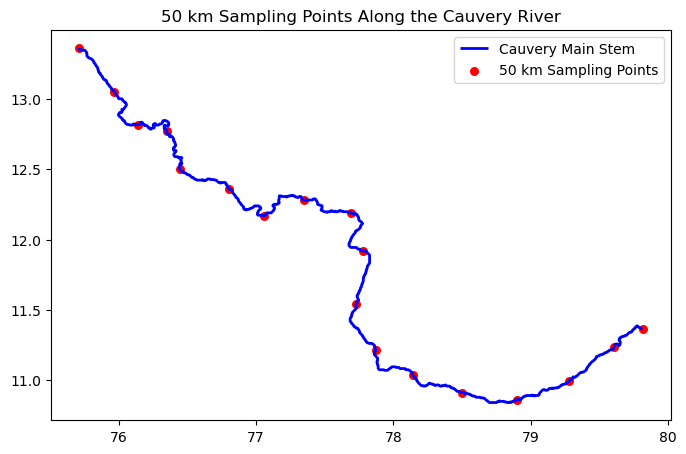

In [87]:
# =====================================================
# SECTION 10.8 – Plot Sampling Points
# =====================================================

fig, ax = plt.subplots(figsize=(8,12))

gpd.GeoSeries([river_line]).plot(
    ax=ax,
    color="blue",
    linewidth=2,
    label="Cauvery Main Stem"
)

points_wgs.plot(
    ax=ax,
    color="red",
    markersize=30,
    label="50 km Sampling Points"
)

plt.title("50 km Sampling Points Along the Cauvery River")

plt.legend()

plt.show()

In [ ]:
SECTION 10.9 – Export the Sampling Points

In [88]:
# =====================================================
# SECTION 10.9 – Export Sampling Points
# =====================================================

output = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.shp"

points_wgs.to_file(output)

print("Sampling points exported successfully.")

Sampling points exported successfully.


In [ ]:
SECTION 11 – Prepare Sampling Points for Google Earth Engine

In [ ]:
SECTION 11.1 – Examine the Attribute Table

In [89]:
# =====================================================
# SECTION 11.1 – Examine Sampling Points
# =====================================================

points_wgs.head(10)

,Point_ID,Distance_km,geometry
0,1,0.0,POINT (75.71042 13.36667)
1,2,50.0,POINT (75.96728 13.05355)
2,3,100.0,POINT (76.13907 12.81875)
3,4,150.0,POINT (76.35112 12.77196)
4,5,200.0,POINT (76.44375 12.50016)
5,6,250.0,POINT (76.80351 12.35899)
6,7,300.0,POINT (77.06031 12.16875)
7,8,350.0,POINT (77.34798 12.28118)
8,9,400.0,POINT (77.69462 12.18871)
9,10,450.0,POINT (77.78095 11.91875)


In [ ]:
SECTION 11.2 – Extract Coordinates

In [90]:
# =====================================================
# SECTION 11.2 – Extract Latitude & Longitude
# =====================================================

points_wgs["Longitude"] = points_wgs.geometry.x
points_wgs["Latitude"] = points_wgs.geometry.y

points_wgs.head()

,Point_ID,Distance_km,geometry,Longitude,Latitude
0,1,0.0,POINT (75.71042 13.36667),75.710417,13.366667
1,2,50.0,POINT (75.96728 13.05355),75.967285,13.053549
2,3,100.0,POINT (76.13907 12.81875),76.139072,12.818750
3,4,150.0,POINT (76.35112 12.77196),76.351122,12.771956
4,5,200.0,POINT (76.44375 12.50016),76.443750,12.500155


In [ ]:
SECTION 11.3 – Verify Coordinates

In [91]:
# =====================================================
# SECTION 11.3 – Verify Coordinates
# =====================================================

print(points_wgs[[
    "Point_ID",
    "Distance_km",
    "Longitude",
    "Latitude"
]])

    Point_ID  Distance_km  Longitude   Latitude
0          1          0.0  75.710417  13.366667
1          2         50.0  75.967285  13.053549
2          3        100.0  76.139072  12.818750
3          4        150.0  76.351122  12.771956
4          5        200.0  76.443750  12.500155
5          6        250.0  76.803512  12.358988
6          7        300.0  77.060307  12.168750
7          8        350.0  77.347982  12.281185
8          9        400.0  77.694625  12.188709
9         10        450.0  77.780955  11.918750
10        11        500.0  77.731250  11.544386
11        12        550.0  77.871036  11.216464
12        13        600.0  78.139583  11.036732
13        14        650.0  78.501841  10.910417
14        15        700.0  78.899609  10.860417
15        16        750.0  79.278385  10.990886
16        17        800.0  79.607195  11.232195
17        18        850.0  79.814583  11.364583


In [ ]:
SECTION 11.4 – Save as Shapefile

In [92]:
# =====================================================
# SECTION 11.4 – Export Shapefile
# =====================================================

output = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.shp"

points_wgs.to_file(output)

print("Shapefile exported successfully.")

Shapefile exported successfully.


In [ ]:
SECTION 11.5 – Save as GeoJSON

In [93]:
# =====================================================
# SECTION 11.5 – Export GeoJSON
# =====================================================

geojson = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.geojson"

points_wgs.to_file(
    geojson,
    driver="GeoJSON"
)

print("GeoJSON exported successfully.")

GeoJSON exported successfully.


In [ ]:
SECTION 11.6 – Save as CSV

In [94]:
# =====================================================
# SECTION 11.6 – Export CSV
# =====================================================

csv_file = r"G:\OCR\hydroriver\Cauvery_50km_SamplingPoints.csv"

points_wgs.drop(columns="geometry").to_csv(
    csv_file,
    index=False
)

print("CSV exported successfully.")

CSV exported successfully.


In [ ]:
SECTION 12.1 – Upload the Shapefile

In [ ]:
SECTION 12.2 – Import the Asset

In [95]:
ee.FeatureCollection("projects/oc-flux/assets/Cauvery_50km_Points")

In [ ]:
Display the Sampling Points

In [97]:
# =====================================================
# SECTION 12.1 – Display Sampling Points
# =====================================================

Map = geemap.Map()

Map.centerObject(points, 8)

Map.addLayer(
    points,
    {"color": "red"},
    "50 km Sampling Points"
)

Map

Map(center=[11.923941212512156, 77.6221773134291], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
Count the Sampling Points

In [98]:
# =====================================================
# SECTION 12.2 – Number of Sampling Points
# =====================================================

print("Number of Sampling Points:")

print(points.size().getInfo())

Number of Sampling Points:
18


In [ ]:
Inspect the First Point

In [99]:
# =====================================================
# SECTION 12.3 – First Sampling Point
# =====================================================

first_point = points.first()

print(first_point.getInfo())

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [75.71041666666636, 13.366666666666466]}, 'id': '0', 'properties': {'Distance_k': 0, 'Latitude': 13.366666666666466, 'Longitude': 75.71041666666636, 'Point_ID': 1}}


In [ ]:
Display Point Attributes

In [108]:
# =====================================================
# SECTION 12.4 – Display Attributes
# =====================================================

points_info = points.getInfo()

for feature in points_info["features"]:

    print(feature["properties"])

{'Distance_k': 0, 'Latitude': 13.366666666666466, 'Longitude': 75.71041666666636, 'Point_ID': 1}
{'Distance_k': 50, 'Latitude': 13.053548632071127, 'Longitude': 75.96728478805915, 'Point_ID': 2}
{'Distance_k': 100, 'Latitude': 12.818750061450949, 'Longitude': 76.1390720041158, 'Point_ID': 3}
{'Distance_k': 150, 'Latitude': 12.771955634969824, 'Longitude': 76.35112225725183, 'Point_ID': 4}
{'Distance_k': 200, 'Latitude': 12.50015510335735, 'Longitude': 76.443749992942, 'Point_ID': 5}
{'Distance_k': 250, 'Latitude': 12.358987737083945, 'Longitude': 76.80351234165879, 'Point_ID': 6}
{'Distance_k': 300, 'Latitude': 12.168750002461435, 'Longitude': 77.06030702542073, 'Point_ID': 7}
{'Distance_k': 350, 'Latitude': 12.281184991262812, 'Longitude': 77.34798167672137, 'Point_ID': 8}
{'Distance_k': 400, 'Latitude': 12.188708706743439, 'Longitude': 77.694624640407, 'Point_ID': 9}
{'Distance_k': 450, 'Latitude': 11.91875018295846, 'Longitude': 77.78095498070532, 'Point_ID': 10}
{'Distance_k': 500,

In [ ]:
Add the Cauvery Main Stem

In [109]:
# =====================================================
# SECTION 12.5 – Load Main Cauvery River
# =====================================================

river = geemap.shp_to_ee(
    r"G:\OCR\hydroriver\Main_Cauvery.shp"
)

Map.addLayer(
    river,
    {
        "color": "blue"
    },
    "Main Cauvery"
)

Map

Map(bottom=15588.0, center=[11.953349393643416, 79.30480957031251], controls=(WidgetControl(options=['position…

In [ ]:
SECTION 13 – Load Landsat Collection and Visualize Imagery

In [ ]:
SECTION 13.1 – Load the Main Cauvery River

In [114]:
# =====================================================
# SECTION 13.1 – Load Main Cauvery River
# =====================================================

river = geemap.shp_to_ee(
    r"G:\OCR\hydroriver\Main_Cauvery.shp"
)

Map = geemap.Map()

Map.addLayer(
    river,
    {"color":"blue"},
    "Main Cauvery"
)

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
SECTION 13.2 – Add the Sampling Points

In [115]:
# =====================================================
# SECTION 13.2 – Add Sampling Points
# =====================================================

Map.addLayer(
    points,
    {"color":"red"},
    "50 km Sampling Points"
)

Map

Map(bottom=812.0, center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [116]:
SECTION 13.3 – Load Landsat 8 Collection

SyntaxError: invalid character '–' (U+2013) (4147716245.py, line 1)

In [117]:
# =====================================================
# SECTION 13.3 – Landsat Collection
# =====================================================

landsat = ee.ImageCollection(
    "LANDSAT/LC08/C02/T1_L2"
)

In [ ]:
SECTION 13.4 – Filter by Rive

In [118]:
# =====================================================
# SECTION 13.4 – Filter by River
# =====================================================

landsat = landsat.filterBounds(river)

In [ ]:
SECTION 13.5 – Filter by Date

In [119]:
# =====================================================
# SECTION 13.5 – Filter by Date
# =====================================================

landsat = landsat.filterDate(
    "2023-01-01",
    "2023-12-31"
)

In [ ]:
SECTION 13.6 – Remove Cloudy Images

In [120]:
# =====================================================
# SECTION 13.6 – Cloud Filter
# =====================================================

landsat = landsat.filter(
    ee.Filter.lt("CLOUD_COVER", 20)
)

In [ ]:
SECTION 13.7 – Count Images

In [121]:
# =====================================================
# SECTION 13.7 – Number of Images
# =====================================================

print(
    "Images Found:",
    landsat.size().getInfo()
)

Images Found: 76


In [ ]:
SECTION 13.8 – Display First Image

In [124]:
# =====================================================
# SECTION 13.8 – Display First Image
# =====================================================

image = landsat.first()

Map.centerObject(
    river,
    8
)

Map.addLayer(
    image,
    {
        "bands":["SR_B4","SR_B3","SR_B2"],
        "min":7000,
        "max":15000
    },
    "Landsat RGB"
)

Map

Map(bottom=30899.0, center=[11.82734269115227, 77.21707593703306], controls=(WidgetControl(options=['position'…

In [ ]:
SECTION 14 – Cloud Masking and Surface Reflectance Preparation

In [130]:
# =====================================================
# SECTION 14.1 – Cloud Mask Function
# =====================================================

def mask_landsat(image):
    """
    Masks clouds, cloud shadows and saturated pixels
    for Landsat Collection 2 Level-2.
    """

    qa = image.select("QA_PIXEL")

    cloud_shadow = 1 << 4
    snow = 1 << 5
    cloud = 1 << 3

    mask = (
        qa.bitwiseAnd(cloud_shadow).eq(0)
        .And(qa.bitwiseAnd(cloud).eq(0))
        .And(qa.bitwiseAnd(snow).eq(0))
    )

    saturation = image.select("QA_RADSAT").eq(0)

    return (
        image
        .updateMask(mask)
        .updateMask(saturation)
    )

In [131]:
# =====================================================
# SECTION 14.2 – Apply Cloud Mask
# =====================================================

landsat_masked = landsat.map(mask_landsat)

print(
    "Masked Images:",
    landsat_masked.size().getInfo()
)

Masked Images: 76


In [133]:
# =====================================================
# SECTION 14.3 – Scale Reflectance
# =====================================================

def apply_scale(image):

    optical = (
        image
        .select("SR_B.*")
        .multiply(0.0000275)
        .add(-0.2)
    )

    return image.addBands(
        optical,
        overwrite=True
    )

In [134]:
# =====================================================
# SECTION 14.4 – Apply Scale Factors
# =====================================================

landsat_sr = landsat_masked.map(apply_scale)

print(
    "Scaled Collection:",
    landsat_sr.size().getInfo()
)

Scaled Collection: 76


In [135]:
# =====================================================
# SECTION 14.5 – Display Processed Image
# =====================================================

image = landsat_sr.first()

Map = geemap.Map()

Map.centerObject(river, 8)

Map.addLayer(
    image,
    {
        "bands": ["SR_B4", "SR_B3", "SR_B2"],
        "min": 0,
        "max": 0.3
    },
    "Scaled Surface Reflectance"
)

Map.addLayer(
    river,
    {"color": "blue"},
    "Main Cauvery"
)

Map.addLayer(
    points,
    {"color": "red"},
    "Sampling Points"
)

Map

Map(center=[11.82734269115226, 77.21707593703307], controls=(WidgetControl(options=['position', 'transparent_b…

In [137]:
# =====================================================
# SECTION 14.6 – Inspect Band Information
# =====================================================

band_names = image.bandNames().getInfo()

print("Bands:")

print(band_names)

Bands:
['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT']


In [ ]:
SECTION 15 – Extract Mean Surface Reflectance Using a 60 m Buffer

In [147]:
# =====================================================
# SECTION 15.1 – Create 60 m Buffers
# =====================================================

buffer_distance = 60   # metres

points_buffer = points.map(
    lambda f: f.buffer(buffer_distance)
)

print("Buffered points created.")

Buffered points created.


In [148]:
# =====================================================
# SECTION 15.2 – Display Buffers
# =====================================================

Map = geemap.Map()

Map.centerObject(river, 8)

Map.addLayer(
    river,
    {"color":"blue"},
    "Main Cauvery"
)

Map.addLayer(
    points_buffer,
    {"color":"yellow"},
    "60 m Buffer"
)

Map

Map(center=[11.82734269115226, 77.21707593703307], controls=(WidgetControl(options=['position', 'transparent_b…

In [149]:
# =====================================================
# SECTION 15.3 – Extract Mean Reflectance
# =====================================================

def extract_buffer_reflectance(image):

    date = image.date().format("YYYY-MM-dd")

    result = image.reduceRegions(
        collection=points_buffer,
        reducer=ee.Reducer.mean(),
        scale=30
    )

    result = result.map(
        lambda f: f.set("Date", date)
    )

    return result

In [150]:
# =====================================================
# SECTION 15.4 – Extract from All Images
# =====================================================

reflectance = (
    landsat_selected
    .map(extract_buffer_reflectance)
    .flatten()
)

print("Extraction Finished")

Extraction Finished


In [151]:
# =====================================================
# SECTION 15.5 – Number of Samples
# =====================================================

print(
    "Total Samples:",
    reflectance.size().getInfo()
)

Total Samples: 1368


In [ ]:
SECTION 16 – Convert Earth Engine Results to a Pandas DataFrame

In [152]:
# =====================================================
# SECTION 16.1 – Convert FeatureCollection
# =====================================================

reflectance_dict = reflectance.getInfo()

print("Conversion Complete")

Conversion Complete


In [153]:
features = reflectance_dict["features"]

print("Number of Features:", len(features))

Number of Features: 1368


In [154]:
import pandas as pd

records = []

for feature in features:

    props = feature["properties"]

    records.append(props)

df = pd.DataFrame(records)

print(df.shape)

df.head()

(1368, 11)


,Date,Distance_k,Latitude,Longitude,Point_ID,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
0,2023-02-22,0,13.366667,75.710417,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-22,50,13.053549,75.967285,2,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-02-22,100,12.818750,76.139072,3,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-02-22,150,12.771956,76.351122,4,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-02-22,200,12.500155,76.443750,5,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
print(df.columns.tolist())

['Date', 'Distance_k', 'Latitude', 'Longitude', 'Point_ID', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']


In [156]:
output_csv = r"G:\OCR\hydroriver\Cauvery_Reflectance_2023.csv"

df.to_csv(output_csv, index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
Section 17

In [157]:
# =====================================================
# SECTION 17.1 – Dataset Overview
# =====================================================

print(df.shape)

df.head()

(1368, 11)


,Date,Distance_k,Latitude,Longitude,Point_ID,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
0,2023-02-22,0,13.366667,75.710417,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-22,50,13.053549,75.967285,2,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-02-22,100,12.818750,76.139072,3,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-02-22,150,12.771956,76.351122,4,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-02-22,200,12.500155,76.443750,5,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
# =====================================================
# SECTION 17.2 – Data Types
# =====================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1368 non-null   str    
 1   Distance_k  1368 non-null   int64  
 2   Latitude    1368 non-null   float64
 3   Longitude   1368 non-null   float64
 4   Point_ID    1368 non-null   int64  
 5   SR_B2       228 non-null    float64
 6   SR_B3       228 non-null    float64
 7   SR_B4       228 non-null    float64
 8   SR_B5       228 non-null    float64
 9   SR_B6       228 non-null    float64
 10  SR_B7       228 non-null    float64
dtypes: float64(8), int64(2), str(1)
memory usage: 117.7 KB


In [159]:
# =====================================================
# SECTION 17.3 – Missing Values
# =====================================================

print(df.isnull().sum())

Date             0
Distance_k       0
Latitude         0
Longitude        0
Point_ID         0
SR_B2         1140
SR_B3         1140
SR_B4         1140
SR_B5         1140
SR_B6         1140
SR_B7         1140
dtype: int64


In [160]:
# =====================================================
# SECTION 17.4 – Summary Statistics
# =====================================================

df.describe()

,Distance_k,Latitude,Longitude,Point_ID,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7
count,1368.000000,1368.000000,1368.000000,1368.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
mean,425.000000,11.921308,77.619028,9.500000,0.036823,0.066457,0.064303,0.177207,0.141303,0.091281
std,259.501238,0.778750,1.223510,5.190025,0.021961,0.026601,0.037066,0.097336,0.090526,0.066362
min,0.000000,10.860417,75.710417,1.000000,-0.148461,-0.045364,-0.058704,-0.026228,0.002633,0.002431
25%,200.000000,11.216464,76.443750,5.000000,0.026073,0.049237,0.036993,0.102503,0.074763,0.038949
50%,425.000000,12.043750,77.712937,9.500000,0.035697,0.061972,0.057820,0.188668,0.134600,0.085980
75%,650.000000,12.500155,78.501841,14.000000,0.046088,0.079929,0.084771,0.253308,0.207994,0.131567
max,850.000000,13.366667,79.814583,18.000000,0.094482,0.150172,0.180336,0.400619,0.328227,0.292222


In [164]:
for root, dirs, files in os.walk(folder):
    print(root)
    for f in files:
        print("   ", f)